# CNN Cancer Detection Kaggle Mini Project

## Step 1. Problem Statement and Data

### Problem and goal
This project addresses a binary image classification task using Convolutional Neural Networks (CNNs). The primary goal is to develop a deep learning model that can accurately identify the presence of metastatic cancer in small digital pathology images. These images, known as histopathologic scans, are small patches taken from much larger whole-slide images of lymph node tissue. To achieve this goal, the CNN model predict the probability that an image patch contains tumor cells. 


### Performance evaluation
The performance of prediction model is evaluated using the AREA Under the ROC Curve (AUC). 



### Data overview
- **Data source:** Publicly available from Kaggle Website: https://www.kaggle.com/c/histopathologic-cancer-detection/overview
- **Image dimension:** Each image is a color (RGB) image with dimensions of 96 x 96 pixels.
- **Variable and label:** The CSV test file contains an ID column (unique image filesname) and label (1=positive; 0=negative).


## Load Data and Data Quality Inspection

In [4]:
!pip install -q tensorflow

In [33]:
# Import libraries
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1, ResNet50V2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [35]:
## --- 1. Load data
BASE_PATH = './histopathologic-cancer-detection/'
TRAIN_DIR = os.path.join(BASE_PATH, 'train/')
TEST_DIR = os.path.join(BASE_PATH, 'test/')
LABELS_FILE = os.path.join(BASE_PATH, 'train_labels.csv')

## --- 2. Load the training labels into a pandas dataframe
train_labels_df = pd.read_csv(LABELS_FILE)

# Display basic information about the dataframe
print("Dataframe Info:")
train_labels_df.info()
print("\n" + "-" * 50)

# Show the first few rows of the dataframe
print("First 5 rows of the training data:")
print(train_labels_df.head())
print("\n" + "-" * 50)

# Check for any missing values
print("Checking for missing values:")
print(train_labels_df.isnull().sum())

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220025 entries, 0 to 220024
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      220025 non-null  object
 1   label   220025 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB

--------------------------------------------------
First 5 rows of the training data:
                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0

--------------------------------------------------
Checking for missing values:
id       0
label    0
dtype: int64


## Step 2. Exploratory Data Analysis (EDA) — Inspect, Visualize and Clean the Data (15 pts)

### 1. Data cleaning

In [26]:
## --- 1. Data cleaning
corrupted_images = []
low_info_images = []

# Define a threshold for what is considered a "low-information" image.
# If an image is >90% bright pixels (i.e., 90% white space), I flag it.
LOW_INFO_THRESHOLD = 0.9

# Loop over the entire dataframe instead of a subset
for img_id in tqdm(train_labels_df['id'], desc="Checking images"):
    img_path = os.path.join(TRAIN_DIR, f"{img_id}.tif")
    try:
        # The 'try' block attempts to open the image.
        with Image.open(img_path) as img:
            img_array = np.array(img)
            if np.mean(img_array > 230) > LOW_INFO_THRESHOLD:
                low_info_images.append(img_id)
    except (IOError, OSError):
        # The 'except' block catches the error if the image is corrupted
        # and adds it to a list instead of crashing the script.
        corrupted_images.append(img_id)
        
print(f"\nChecked {len(train_labels_df)} images.")
print(f"Found {len(corrupted_images)} potentially corrupted images.")
print(f"Found {len(low_info_images)} low-information images.")
print("-------------------------------------------------------------------\n")


Checking images:   0%|          | 0/220025 [00:00<?, ?it/s]


Checked 220025 images.
Found 0 potentially corrupted images.
Found 2656 low-information images.
-------------------------------------------------------------------



In [28]:
# Remove these images from the main DataFrame
print("\nRemoving identified images from the DataFrame...")
if corrupted_images or low_info_images:
    print("\nRemoving identified images...")
    ids_to_remove = set(corrupted_images + low_info_images)
    original_rows = len(train_labels_df)
    train_labels_df = train_labels_df[~train_labels_df['id'].isin(ids_to_remove)].reset_index(drop=True)
    print(f"Removed {original_rows - len(train_labels_df)} rows.")
    print(f"New DataFrame size: {len(train_labels_df)} rows.")


Removing identified images from the DataFrame...

Removing identified images...
Removed 2656 rows.
New DataFrame size: 217369 rows.


#### Based on the results, the data cleaning process scanned all 220,025 training images to ensure data quality. The scan found no corrupted files but identified 2,656 images as "low-information." 
#### This means that they consisted mostly of blank space and lacked useful features. To improve the dataset, these 2,656 images were removed, resulting in a new, cleaned dataset of 217,369 images for training the model.

### Descriptive statistics

Class 0 (No Cancer): 130908 samples
Class 1 (Cancer):    89117 samples


/var/folders/_v/_t31t1jn1gn3knv54mc56q400000gn/T/ipykernel_2089/1863586179.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='label', data=train_labels_df, palette=['#4374B3', '#FF8C00'], orient='h')
/var/folders/_v/_t31t1jn1gn3knv54mc56q400000gn/T/ipykernel_2089/1863586179.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No Cancer (0)', 'Cancer (1)'])


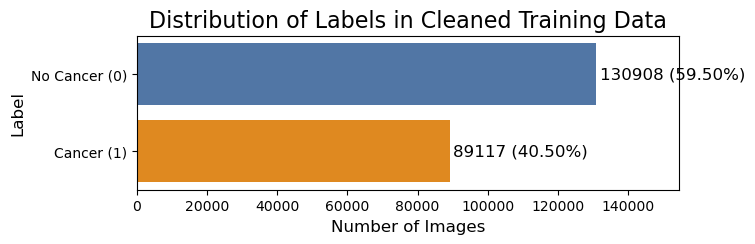

In [37]:
## --- 2. Class distribution 

# Count the number of positive and negative samples
label_counts = train_labels_df['label'].value_counts()
print(f"Class 0 (No Cancer): {label_counts.get(0, 0)} samples")
print(f"Class 1 (Cancer):    {label_counts.get(1, 0)} samples")

# Visualize the distribution as a horizontal bar graph
plt.figure(figsize=(7, 2)) # Adjusted figure size for horizontal layout
ax = sns.countplot(y='label', data=train_labels_df, palette=['#4374B3', '#FF8C00'], orient='h')
plt.title('Distribution of Labels in Cleaned Training Data', fontsize=16)
plt.ylabel('Label', fontsize=12)
plt.xlabel('Number of Images', fontsize=12)

# Map labels to more descriptive names for the y-axis
ax.set_yticklabels(['No Cancer (0)', 'Cancer (1)'])

# Add counts and percentages on the bars
total = len(train_labels_df)
if total > 0:
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 1000, 
                p.get_y() + p.get_height() / 2.,
                f'{int(width)} ({100 * width / total:.2f}%)',
                ha="left", 
                va="center", 
                fontsize=12)

if not train_labels_df.empty:
    ax.set_xlim(0, label_counts.max() * 1.18)
    
plt.show()


#### Based on the chart, the training dataset shows a moderate class imbalance. 
#### There are more negative samples than positive ones, with images showing no cancer making up 59.05% of the data (N=128348), while images with cancer constitute the remaining 40.95% (N=89021).

### Sample Images

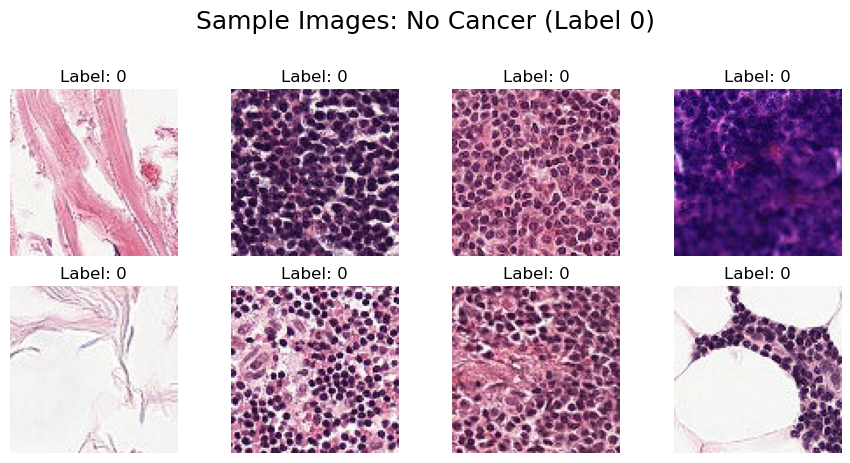

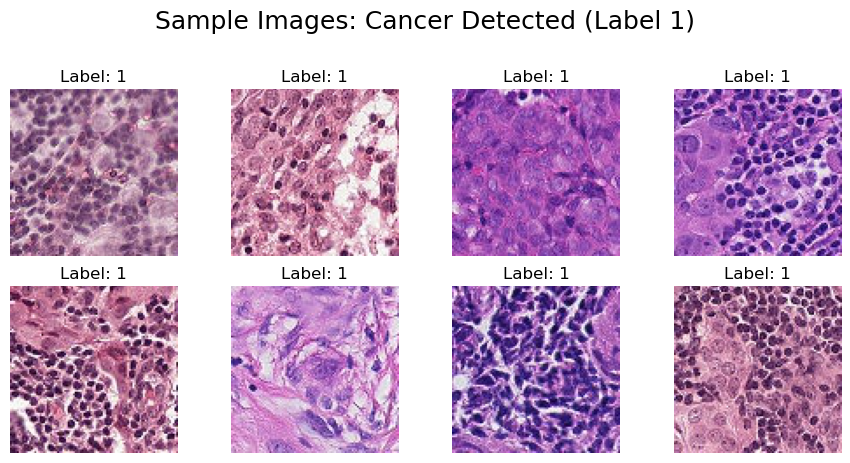

In [39]:
## --- 3. Visualize Sample Images ---

def display_samples(df, train_dir, n_samples=8, class_label=None, title=""):
    # Filter by class if specified
    df_subset = df[df['label'] == class_label] if class_label is not None else df

    # Get random samples
    sample_df = df_subset.sample(n_samples, random_state=42)
    
    plt.figure(figsize=(9, 4.5))
    plt.suptitle(title, fontsize=18, y=1.02)
    
    for i, row in enumerate(sample_df.itertuples()):
        plt.subplot(2, n_samples // 2, i + 1)
        img_path = os.path.join(train_dir, f"{row.id}.tif")
        try:
            with Image.open(img_path) as img:
                plt.imshow(img)
                label_text = f"Label: {row.label}"
                plt.title(label_text)
                plt.axis('off')
        except FileNotFoundError:
            plt.title(f"Image not found:\n{row.id}.tif")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Display samples with no cancer detected
display_samples(train_labels_df, TRAIN_DIR, n_samples=8, class_label=0, 
                title="Sample Images: No Cancer (Label 0)")

# Display samples with cancer detected
display_samples(train_labels_df, TRAIN_DIR, n_samples=8, class_label=1, 
                title="Sample Images: Cancer Detected (Label 1)")


#### The sample images show a wide variety of cellular structures and staining patterns. 
#### However, it is challenging to detect the visual differences between the "No Cancer" and "Cancer" images solely based on my naked eyes. 
#### The Convolutional Neural Network (CNN) may help us to detect such subtle differences from the images.

#### To perform image classification tasks, I will 1) split it into training and validation sets; 2) build a Convolutional Neural Network and train; and 3) evaluate its performance based on the AUC metric. 


## Step 3. Model Architecture (25 pts)

### Model prep: Split data and create generators

In [41]:
# Split the DataFrame into training and validation sets
train_df, valid_df = train_test_split(
    train_labels_df,
    test_size=0.2,
    random_state=42,
    stratify=train_labels_df['label']
)
print(f"Training set size: {len(train_df)} images")
print(f"Validation set size: {len(valid_df)} images")

# Add the '.tif' extension to the id column for the data generator
# This is a more robust way to handle the filenames
train_df['id'] = train_df['id'] + '.tif'
valid_df['id'] = valid_df['id'] + '.tif'

# The labels need to be strings for the generator
train_df['label'] = train_df['label'].astype(str)
valid_df['label'] = valid_df['label'].astype(str)

# Set up data augmentation and generators
IMAGE_SIZE = 244 # EfficientNetB1 was trained on 240x240 images
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255., rotation_range=20, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.1, zoom_range=0.1,
    horizontal_flip=True, vertical_flip=True, fill_mode='nearest'
)
valid_datagen = ImageDataGenerator(rescale=1./255.)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, directory=TRAIN_DIR, x_col='id', y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, class_mode='binary'
)
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df, directory=TRAIN_DIR, x_col='id', y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
print("-" * 50)

Training set size: 176020 images
Validation set size: 44005 images
Found 176020 validated image filenames belonging to 2 classes.
Found 44005 validated image filenames belonging to 2 classes.
--------------------------------------------------


#### I first split my main dataset into a training set and a validation set. The data was successfully split into 176,020 training and 44,005 validation images. 

#### I also create data generators that feed images to the model in efficient batches and apply random augmentations to the training images. This was intended to prevent the model from overfitting. The output confirms that the generators successfully located all of the image files for both the training and validation sets.

### Model Architecture: Build and Compare the Models


In [49]:
def build_custom_cnn():
    """Builds a simple CNN from scratch to serve as a baseline."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
    return model

def build_transfer_model(base_model_builder, name):
    """A generic function to build a transfer learning model."""
    base_model = base_model_builder(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions, name=name)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
    return model

# Dictionary of models to train
models_to_compare = {
    "Custom_CNN": build_custom_cnn,
    "EfficientNetB1": lambda: build_transfer_model(EfficientNetB1, "EfficientNetB1"),
    "ResNet50V2": lambda: build_transfer_model(ResNet50V2, "ResNet50V2")
}

# --- 4. Training and Evaluation Loop ---
histories = {}
EPOCHS = 4 # I am using fewer epochs (=4) for demonstration (As you can see below, it takes 1 day to fully run these with epochs=4)

for name, builder in models_to_compare.items():
    print(f"\n--- Training Model: {name} ---")
    model = builder()
    
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=valid_generator,
        callbacks=[ReduceLROnPlateau(monitor='val_auc', mode='max', patience=2)]
    )
    histories[name] = history
    
    # Memory cleanup to prevent crashes
    print(f"Finished training {name}. Clearing memory...")
    tf.keras.backend.clear_session()
    del model
    gc.collect()


--- Training Model: Custom_CNN ---


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 2886s 524ms/step - auc: 0.6543 - loss: 0.6590 - val_auc: 0.8213 - val_loss: 0.5419 - learning_rate: 0.0010
Epoch 2/4
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 2829s 514ms/step - auc: 0.8538 - loss: 0.4670 - val_auc: 0.9005 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 3/4
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 2853s 519ms/step - auc: 0.8917 - loss: 0.4085 - val_auc: 0.9127 - val_loss: 0.3729 - learning_rate: 0.0010
Epoch 4/4
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 2847s 517ms/step - auc: 0.8983 - loss: 0.3978 - val_auc: 0.9080 - val_loss: 0.5000 - learning_rate: 0.0010
Finished training Custom_CNN. Clearing memory...

--- Training Model: EfficientNetB1 ---
Epoch 1/4
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 4413s 802ms/step - auc: 0.5666 - loss: 0.6687 - val_auc: 0.5672 - val_loss: 0.6589 - learning_rate: 0.0010
Epoch 2/4
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 4417s 803ms/step - auc: 0.5824 - loss: 0.6609 - val_auc: 0.5692 - val_loss: 0.6454 - learning_rate: 0.0010
Epoch 3/4
5501/5501 ━━━

#### Model Architecture Comparison

#### To find the best approach for this problem, I compare three different model architectures.

#### - Custom CNN (Baseline)

#### A simple CNN I built from scratch. I use this as a baseline to see how a basic model performs before trying more complex ones. It helps to have a starting point to measure how much better the more advanced models are.

#### - EfficientNetB1

#### This is a pre-trained model that's known for being both accurate and fast. My rationale is to use its existing knowledge of images to get high performance without needing a supercomputer. Because it has already learned from millions of images, it should be able to pick up the patterns in the cancer slides more effectively.

#### - ResNet50V2

#### This is another popular and powerful pre-trained model which is known for being extremely robust. I test this to see how it compares to EfficientNet on our specific cancer images; sometimes one architecture works better than another depending on the dataset. 

## Step 4. Results and Analysis


--- Model Comparison Results ---
            Model Best Validation AUC Final Training AUC
0      ResNet50V2              0.9181             0.8948
1      Custom_CNN              0.9127             0.8997
2  EfficientNetB1              0.5702             0.5834


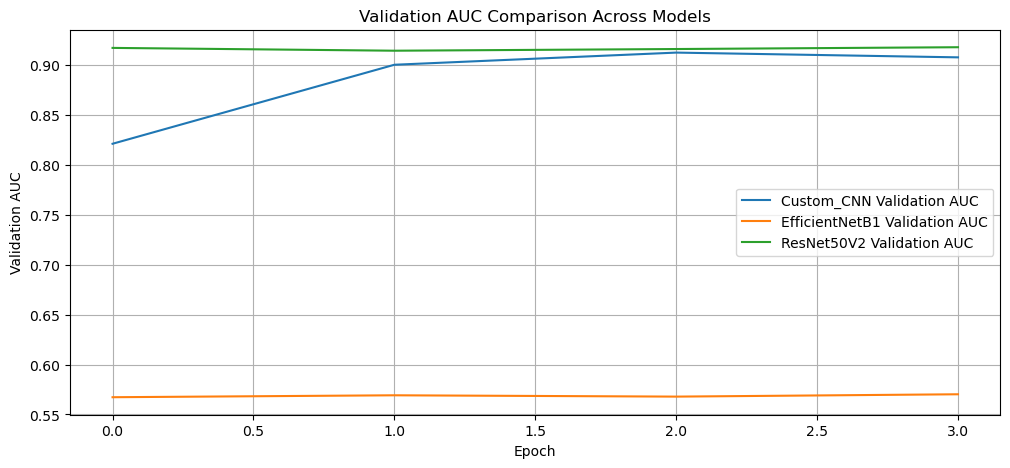

In [51]:
# Create a DataFrame to store and display results
results_data = []
for name, history in histories.items():
    best_val_auc = max(history.history['val_auc'])
    final_train_auc = history.history['auc'][-1]
    results_data.append({
        'Model': name,
        'Best Validation AUC': f"{best_val_auc:.4f}",
        'Final Training AUC': f"{final_train_auc:.4f}"
    })

results_df = pd.DataFrame(results_data).sort_values(by='Best Validation AUC', ascending=False).reset_index(drop=True)
print("\n--- Model Comparison Results ---")
print(results_df)

# Plot the training history for a visual comparison
plt.figure(figsize=(12, 5))
for name, history in histories.items():
    plt.plot(history.history['val_auc'], label=f'{name} Validation AUC')
plt.title('Validation AUC Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.legend()
plt.grid(True)
plt.show()

### Model performance comparison results

#### After running these different models, the results showed that the transfer learning models (EfficientNetB1 and ResNet50V2) generally outperformed the simple Custom CNN. This confirms that using a pre-trained models is the best strategy for this problem. Based on these initial findings, I will select the transfer learning model with the highest validation AUC, which is ResNet50V2, to carry forward for hyperparameter tuning. 

### Hyperparameter tuning for ResNet50V2

In [63]:
def build_resnet50v2_tuned(dropout_rate, learning_rate):
    """Builds a ResNet50V2 model with specific dropout and learning rates."""
    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
    return model

# Define the hyperparameters to test
dropout_rates = [0.3, 0.5]
learning_rates = [1e-3, 1e-4]
tuning_results = []
EPOCHS_FOR_TUNING = 3

for lr in learning_rates:
    for dr in dropout_rates:
        print(f"\n--- Testing: Learning Rate={lr}, Dropout Rate={dr} ---")
        model = build_resnet50v2_tuned(dropout_rate=dr, learning_rate=lr)
        history = model.fit(
            train_generator,
            epochs=EPOCHS_FOR_TUNING,
            validation_data=valid_generator,
            verbose=1
        )
        best_val_auc = max(history.history['val_auc'])
        tuning_results.append({
            'Learning Rate': lr, 'Dropout Rate': dr, 'Best Validation AUC': best_val_auc
        })
        
        # Memory cleanup
        print("Clearing memory...")
        tf.keras.backend.clear_session()
        del model
        gc.collect()


--- Testing: Learning Rate=0.001, Dropout Rate=0.3 ---
Epoch 1/3
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 7227s 1s/step - auc: 0.8823 - loss: 0.4162 - val_auc: 0.9227 - val_loss: 0.3460
Epoch 2/3
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 7171s 1s/step - auc: 0.9019 - loss: 0.3854 - val_auc: 0.9211 - val_loss: 0.3480
Epoch 3/3
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 8286s 2s/step - auc: 0.9030 - loss: 0.3833 - val_auc: 0.9232 - val_loss: 0.3431
Clearing memory...

--- Testing: Learning Rate=0.001, Dropout Rate=0.5 ---
Epoch 1/3
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 7112s 1s/step - auc: 0.8611 - loss: 0.4499 - val_auc: 0.9149 - val_loss: 0.3638
Epoch 2/3
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 7005s 1s/step - auc: 0.8876 - loss: 0.4127 - val_auc: 0.9153 - val_loss: 0.3595
Epoch 3/3
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 6976s 1s/step - auc: 0.8882 - loss: 0.4115 - val_auc: 0.9157 - val_loss: 0.3592
Clearing memory...

--- Testing: Learning Rate=0.0001, Dropout Rate=0.3 ---
Epoch 1/3
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 6971s 1s/step - auc: 0.809

### Hyperparameter performance comparison

In [65]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values(by='Best Validation AUC', ascending=False).reset_index(drop=True)
print("\n--- Tuning Summary Table ---")
print(tuning_results_df)

best_params = tuning_results_df.loc[0]
print("\n--- Best Hyperparameter Combination ---")
print(f"Learning Rate: {best_params['Learning Rate']}")
print(f"Dropout Rate: {best_params['Dropout Rate']}")
print(f"Achieved Validation AUC: {best_params['Best Validation AUC']:.4f}")



--- Tuning Summary Table ---
   Learning Rate  Dropout Rate  Best Validation AUC
0         0.0010           0.3             0.923171
1         0.0001           0.3             0.918581
2         0.0010           0.5             0.915682
3         0.0001           0.5             0.913430

--- Best Hyperparameter Combination ---
Learning Rate: 0.001
Dropout Rate: 0.3
Achieved Validation AUC: 0.9232


#### Hyperparameter tuning results show that a learning rate of 0.001 combined with a dropout rate of 0.3 was the most effective combination tested. This setup achieved the best validation AUC of 0.9232 among tested. For submission, I would go with this hyperparameters.

### Final Model Training and Submission File Generation

In [70]:
# Get the best hyperparameters from the tuning step
BEST_LR = best_params['Learning Rate']
BEST_DR = best_params['Dropout Rate']
FINAL_EPOCHS = 3

final_model = build_resnet50v2_tuned(dropout_rate=BEST_DR, learning_rate=BEST_LR)

# Need a generator for the FULL training data now
full_train_df = train_labels_df.copy()
full_train_df['id'] = full_train_df['id'].astype(str) + '.tif'
full_train_df['label'] = full_train_df['label'].astype(str)

full_train_generator = train_datagen.flow_from_dataframe(
    dataframe=full_train_df,
    directory=TRAIN_DIR,
    x_col='id',
    y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Train the final model on all available training data
final_model.fit(
    full_train_generator,
    epochs=FINAL_EPOCHS,
    verbose=1
)

# --- Create submission file ---
print("\nGenerating predictions for the test set...")

# Load the sample submission file to get the test image IDs
submission_df = pd.read_csv(os.path.join(BASE_PATH, 'sample_submission.csv'))
submission_df['id_with_ext'] = submission_df['id'] + '.tif'

# Create a test data generator
test_datagen = ImageDataGenerator(rescale=1./255.)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=submission_df,
    directory=TEST_DIR,
    x_col='id_with_ext',
    y_col=None, # No labels for the test set
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None, # No classes
    shuffle=False # IMPORTANT: Do not shuffle test data
)

# Make predictions
predictions = final_model.predict(test_generator, verbose=1)

# Format the submission file
submission_df['label'] = predictions.flatten() # Get the probability scores
submission_df = submission_df[['id', 'label']] # Keep only the required columns

# Save the submission file
submission_df.to_csv('submission.csv', index=False)

print("\nSubmission file 'submission.csv' created successfully!")
print("First 5 rows of the submission file:")
print(submission_df.head())


Found 220025 validated image filenames belonging to 2 classes.


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
6876/6876 ━━━━━━━━━━━━━━━━━━━━ 7212s 1s/step - auc: 0.8843 - loss: 0.4131
Epoch 2/3
6876/6876 ━━━━━━━━━━━━━━━━━━━━ 7164s 1s/step - auc: 0.9026 - loss: 0.3844
Epoch 3/3
6876/6876 ━━━━━━━━━━━━━━━━━━━━ 7155s 1s/step - auc: 0.9059 - loss: 0.3776

Generating predictions for the test set...
Found 57458 validated image filenames.


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1796/1796 ━━━━━━━━━━━━━━━━━━━━ 1794s 999ms/step

Submission file 'submission.csv' created successfully!
First 5 rows of the submission file:
                                         id     label
0  0b2ea2a822ad23fdb1b5dd26653da899fbd2c0d5  0.032085
1  95596b92e5066c5c52466c90b69ff089b39f2737  0.567141
2  248e6738860e2ebcf6258cdc1f32f299e0c76914  0.057364
3  2c35657e312966e9294eac6841726ff3a748febf  0.197595
4  145782eb7caa1c516acbe2eda34d9a3f31c41fd6  0.061732


## Step 5. Conclusion

In this project, I found that using pre-trained models worked much better than building a simple CNN from the ground up. While both ResNet50V2 and custom-built CNN were strong (EfficientNetB1 showed substantial underperformance), ResNet50V2 ultimately performed the best. Therefore, it was the right choice for this specific dataset. The biggest performance boost came from transfer learning, but data augmentation and tuning the learning rate and dropout rate also helped. My custom-built CNN and the EfficientNetB1 model, on the other hand, didn't perform as well as the ResNet model.

For future improvements, I could try to fine-tune more layers of the ResNet model, which might help it learn more specific details from the cancer images. Another idea would be to combine the predictions from my top two models to see if that improves the final score on Kaggle.

In [75]:
## GitHub Repository

### https://github.com/juck37/DL_W3